# Stellar Luminosity

## Setup


In [1]:
# Install required libraries (run this once if needed)
%pip install numpy matplotlib

  Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (10.0 MB)
Using cached contourpy-1.3.

In the following we find our dataset, where mass is the stellar mass in units of solar mass and the luminosity is the stellar luminosity in units of solar luminosity.We vectorize it using the library numpy to do numerical computation.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

mass_array = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
luminosity_array = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

## Exploring the dataset

We can plot the mass-luminosity relationship to visualize the shape and range of the variables. We observe in the following function has a exponential shape, this leads us to think that using a linear model could be counterproductive, given that it might show systematic errors, especially,with masses greater than 1.50 because the relationship plots in a more exponential way.

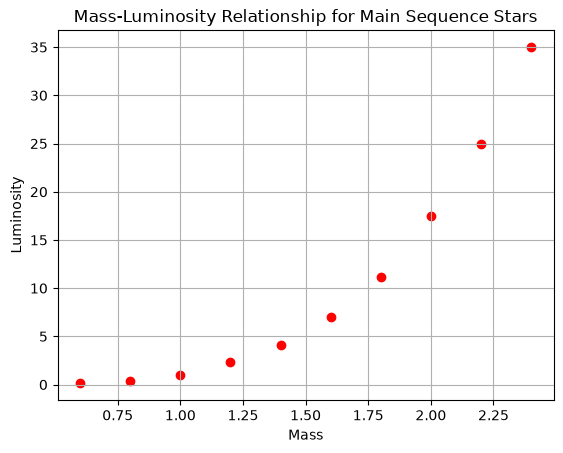

In [5]:
plt.scatter(mass_array,luminosity_array, color='r', label='Data Points')
plt.title('Mass-Luminosity Relationship for Main Sequence Stars')
plt.xlabel('Mass')
plt.ylabel('Luminosity')
plt.grid()

To reforce the hyphotesis of the shape of the relationship being plotted, we use a lynestyle to connect the dots:

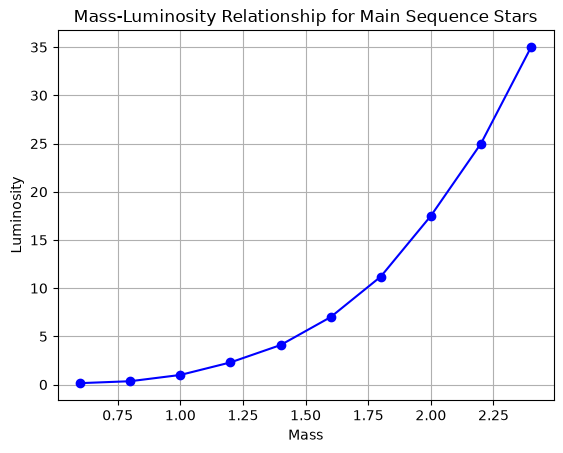

In [6]:
plt.plot(mass_array, luminosity_array, marker='o', linestyle='-', color='b')
plt.title('Mass-Luminosity Relationship for Main Sequence Stars')
plt.xlabel('Mass')
plt.ylabel('Luminosity')
plt.grid()

## Training Learn Functions

In [7]:
def build_polynomial_features(x, degree=2):
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    features = []
    for d in range(1, degree + 1):
        features.append(x ** d)
    return np.column_stack(features)

def predict(X, w, b):
    return X @ w + b

def compute_cost(X, y, w, b):
    m = X.shape[0]
    y_hat = predict(X, w, b)
    errors = y_hat - y
    return np.sum(errors**2) / (2 * m)

def compute_gradients(X, y, w, b):
    m = X.shape[0]
    y_hat = predict(X, w, b)
    errors = y_hat - y
    dj_dw = (X.T @ errors) / m
    dj_db = np.sum(errors) / m
    return dj_dw, dj_db

def gradient_descent(X, y, w_init, b_init, alpha, num_iterations, print_progress=True):
    w = w_init.copy()
    b = b_init
    history_it = []
    history_cost = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradients(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        history_it.append(i)
        history_cost.append(cost)

    return w, b, history_it, history_cost

def feature_scale(X):
    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=0)
    X_scaled = (X - means) / stds
    return X_scaled, means, stds

## Linear Model Training

Below we follow the training procedure step by step:
1. Initialize the parameters.
2. Select a learning rate and the number of iterations.
3. Train the model with gradient descent.
4. Plot the cost over time.
5. Plot the fitted line against the observations.
6. Report the final parameters and cost.
7. Diagnose convergence and possible systematic errors.


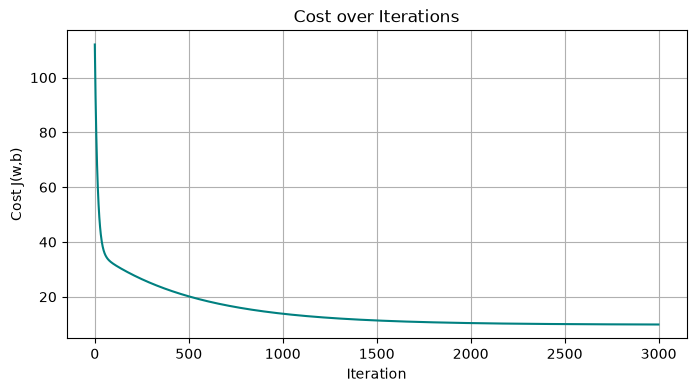

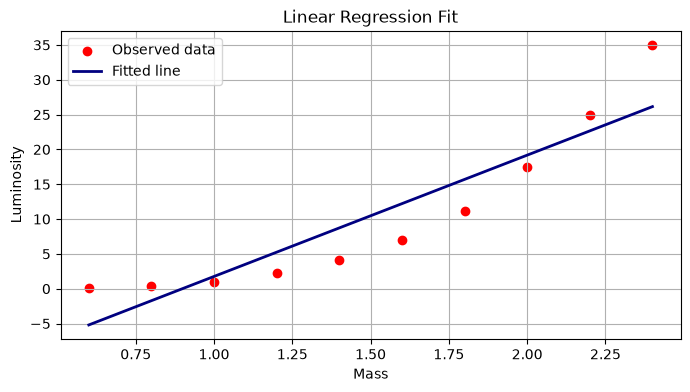

Final parameters: w = [17.41363619], b = -15.648025
Final cost: 9.886215
Residuals:
[-5.34984327 -2.06711603  0.76561121  2.94833844  4.63106568  5.21379292
  4.49652016  1.67924739 -2.33802537 -8.85529813]


In [29]:
x_linear = np.array(mass_array).reshape(-1, 1)

w_init = np.zeros(1)
b_init = 0.0

alpha = 0.01
num_iterations = 3000

# Training
w_final, b_final, history_it, history_cost = gradient_descent(
    x_linear,
    luminosity_array,
    w_init,
    b_init,
    alpha,
    num_iterations,
    print_progress=False
)

# Plotting
iterations = history_it
costs = history_cost

plt.figure(figsize=(8, 4))
plt.plot(iterations, costs, color='teal')
plt.title('Cost over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.grid(True)
plt.show()

# Fitted line with the observations
x_fit = np.linspace(min(x_linear), max(x_linear), 200).reshape(-1, 1)
y_fit = predict(x_fit, w_final, b_final)

plt.figure(figsize=(8, 4))
plt.scatter(x_linear, luminosity_array, color='red', label='Observed data')
plt.plot(x_fit, y_fit, color='navy', linewidth=2, label='Fitted line')
plt.title('Linear Regression Fit')
plt.xlabel('Mass')
plt.ylabel('Luminosity')
plt.grid(True)
plt.legend()
plt.show()


final_cost = compute_cost(x_linear, luminosity_array, w_final, b_final)
print(f"Final parameters: w = {np.array2string(w_final)}, b = {b_final:.6f}")
print(f"Final cost: {final_cost:.6f}")

# Convergence and systematic errors
predictions = predict(x_linear, w_final, b_final)
residuals_linear = predictions - luminosity_array

print("Residuals:")
print(residuals_linear)

As we can see, the fitted line has too many systemic errors when compared to the observed data, showing that a lineal model was not adequate. We see a close match in both the firsgt and eight points of the data -given but the rest of the predictions have a greater error.

## Polynominial Model Training
Below we follow the training procedure step by step:
1. Reuse the same prediction, cost, gradient, and gradient-descent functions.
2. Train the model.
3. Plot its convergence.
4. Plot the fitted curve with the observations.
5. Report the final parameters and cost.
6. Explain what changed in the model and what remained unchanged.


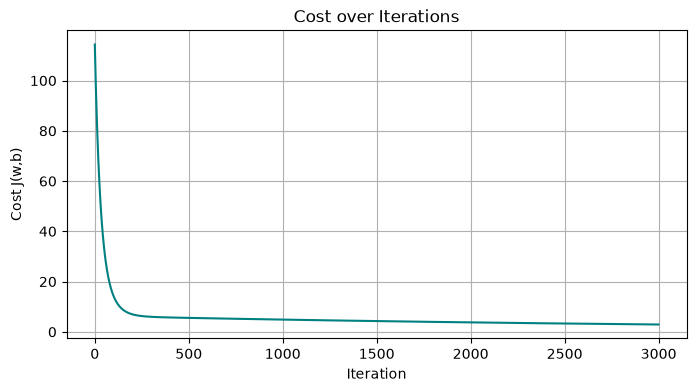

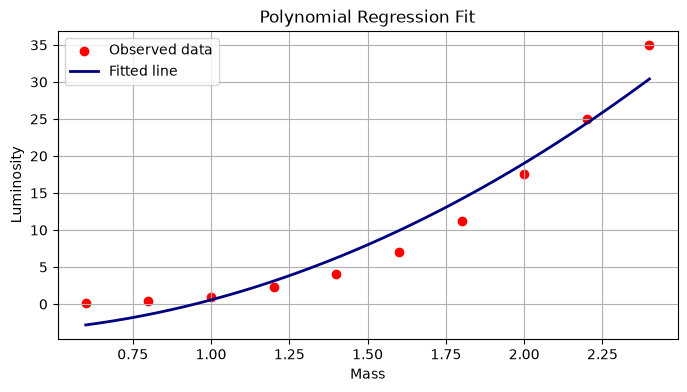

Residuals:
[-2.9754744  -1.77004458 -0.4428614   0.80607512  2.12676499  2.91920821
  2.98340478  1.5193547  -0.57294202 -4.5934854 ]


In [30]:
degree = 2
x_polynomial = build_polynomial_features(mass_array, degree=degree)
x_polynomial_scaled, means_poly, stds_poly = feature_scale(x_polynomial)

w_init = np.zeros(x_polynomial_scaled.shape[1])
b_init = 0.0

w_poly, b_poly, history_it_poly, history_cost_poly = gradient_descent(
    x_polynomial_scaled,
    luminosity_array,
    w_init,
    b_init,
    alpha,
    num_iterations,
    print_progress=False
)

iterations = history_it_poly
costs = history_cost_poly

plt.figure(figsize=(8, 4))
plt.plot(iterations, costs, color='teal')
plt.title('Cost over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.grid(True)
plt.show()

# Fitting the polynomial regression model to the data
x_fit = np.linspace(np.min(mass_array), np.max(mass_array), 200)
x_fit_poly = build_polynomial_features(x_fit, degree=degree)

x_fit_poly_scaled = (x_fit_poly - means_poly) / stds_poly

y_fit = predict(x_fit_poly_scaled, w_poly, b_poly)

plt.figure(figsize=(8, 4))
plt.scatter(mass_array, luminosity_array, color='red', label='Observed data')
plt.plot(x_fit, y_fit, color='navy', linewidth=2, label='Fitted line')
plt.title('Polynomial Regression Fit')
plt.xlabel('Mass')
plt.ylabel('Luminosity')
plt.grid(True)
plt.legend()
plt.show()

predictions_poly = predict(x_polynomial_scaled, w_poly, b_poly)
residuals_poly = predictions_poly - luminosity_array

print("Residuals:")
print(residuals_poly)

As we can see the polynomial of 2nd degree is quite more accurate to the data set given , but it's not fitted enough and still has great errors between 1.25 and 2 units of mass. We also can see how the cost over iterations lowers when more iterations are done, this shows how the model it's learning and has let costs with the pass of time.

## Comparation of both models


In [31]:

linear_cost = compute_cost(x_linear, luminosity_array, w_final, b_final)
poly_cost = compute_cost(x_polynomial_scaled, luminosity_array, w_poly, b_poly)

print("Final costs:")
print(f"Linear model: {linear_cost:.6f}")
print(f"Polynomial model: {poly_cost:.6f}")
print(f"Cost difference (linear - polynomial): {linear_cost - poly_cost:.6f}")

Final costs:
Linear model: 9.886215
Polynomial model: 2.925740
Cost difference (linear - polynomial): 6.960474


Seeing the cost difference, we can see that the polynomial model had a much lower cost than the linear one, this shows how it's more adequate and it's faster at learning and fitting to the data given.

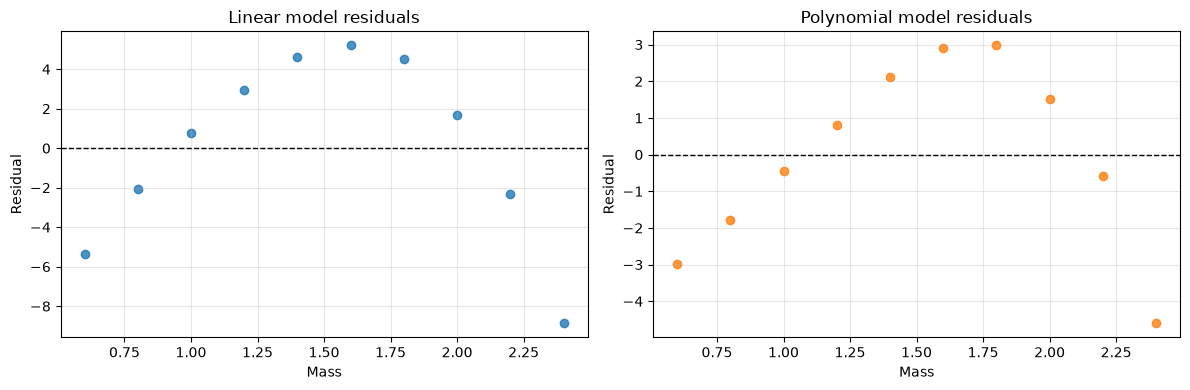

In [32]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(mass_array, residuals_linear, color='tab:blue', alpha=0.8)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Linear model residuals')
axes[0].set_xlabel('Mass')
axes[0].set_ylabel('Residual')
axes[0].grid(alpha=0.3)

axes[1].scatter(mass_array, residuals_poly, color='tab:orange', alpha=0.8)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Polynomial model residuals')
axes[1].set_xlabel('Mass')
axes[1].set_ylabel('Residual')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

As we see on the models residuals, the linear it's more unaccurate in comparison to the polynomial model. In both residuals, the initial hypothesis of more systematic errors around the data in about 1.50 mass it's greater it's proven. 
Also, the relationship between mass and the stellar luminosity is non-linear and it's not captured on any of the models done during the project, which we conclude when observing the clear parabolic shape on both models residuals. This gives us the hypothesis that increasing the polynomical degree could give better results.

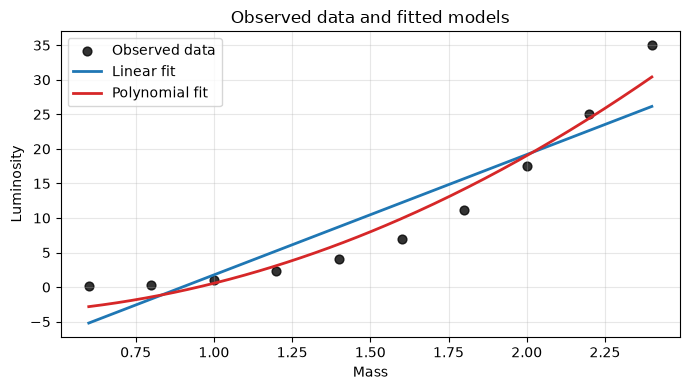

In [33]:

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(mass_array, luminosity_array, color='black', s=40, alpha=0.8, label='Observed data')

x_lin_fit = np.linspace(mass_array.min(), mass_array.max(), 200).reshape(-1, 1)
y_lin_fit = predict(x_lin_fit, w_final, b_final)
ax.plot(x_lin_fit[:, 0], y_lin_fit, color='tab:blue', linewidth=2, label='Linear fit')

x_poly_fit = np.linspace(mass_array.min(), mass_array.max(), 200)
x_poly_fit_features = build_polynomial_features(x_poly_fit, degree=degree)
x_poly_fit_scaled = (x_poly_fit_features - means_poly) / stds_poly
y_poly_fit = predict(x_poly_fit_scaled, w_poly, b_poly)
ax.plot(x_poly_fit, y_poly_fit, color='tab:red', linewidth=2, label='Polynomial fit')

ax.set_title('Observed data and fitted models')
ax.set_xlabel('Mass')
ax.set_ylabel('Luminosity')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Comparing both models we can see how the polynomial fit it's more accurate but not enough to fit the data set given, in comparison to the linear fit that it's only accurate or close to a couple data points.

## Testing of the predictions

We do the following tests of the predictions . At first, we use a mass of 1.3, a range inside the observer range, and we do too a mass of 5.0, that is far outisde the observed range.

In [28]:
test_mass = np.array([1.3, 5.0])

for mass in test_mass:
    x_lin = np.array([[mass]], dtype=float)
    pred_linear = float(predict(x_lin, w_final, b_final)[0])

    x_poly = build_polynomial_features(np.array([mass], dtype=float), degree=degree)
    x_poly_scaled = (x_poly - means_poly) / stds_poly
    pred_poly = float(predict(x_poly_scaled, w_poly, b_poly)[0])

    print(f"mass: {mass:.1f}")
    print(f"linear model: {pred_linear:.3f}")
    print(f"polynomial model: {pred_poly:.3f}")
    print()

mass: 1.3
linear model: 7.393
polynomial model: 4.925

mass: 5.0
linear model: 67.638
polynomial model: 146.388



Based on the results, we can conclude that for the mass of 1.3 both predictions are relativity adequate as interpolations and don't have a great difference but for 5.0 we can't trust the predictions because they are outside the data used to fit the models and show a huge difference.

## Reflections


What does this regression experiment reveal—and what does it fail to reveal—about how more advanced AI systems learn?

This regression experiment shows that more advanced AI systems learn with less cost, more accurately and with less error.But, it doesn't reveal how these systems actually learn in more complex data sets. We can see how a polynomial of degree 2 isn't enough to fit onto the data but can't be sure in what moment we could  incur on overfitting.

Do you think Artificial General Intelligence is achievable? Explain what you understand by AGI and why you believe it is—or is not—reachable.

I think it could be achievable but could take many resources and years of study, AGI is an AI system that can understand, learn and apply knowledge on a variety of tasks like a human.

Could AGI emerge primarily by scaling neural networks with more GPUs, data, and parameters? Or will it require fundamentally different architectures, learning mechanisms, theories, or ways of interacting with the world?

I don't think so, because scaling neural networks with more GPUs, data and parameters will probably improve AI performance, but i think AGI will also require different architectures, learning methods,and others way of interacting with the humans and the real word in general.

One question about AI-driven systems that I want to explore during the semester is: How can enterprise architecture help organizations innovate fast enough to become market disruptors instead of followers?